# Continuous housing investment with frictions: EGM(FUES) vs NEGM(FUES)

In [1]:
import warnings
warnings.filterwarnings('ignore', message='.*IProgress.*')

import numpy as np
import sys, os, time

REPO_ROOT = os.path.abspath('../../..')
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
os.environ['FUES_RETURN_GRIDS'] = '1'

from examples.durables.solve import solve
from examples.durables.horses.simulate import (
    simulate_lifecycle, evaluate_euler_c, evaluate_euler_h,
)
from examples.durables.outputs import (
    setup_nb_style,
    FilteredStdout, get_timing,
    print_solve_summary, build_comparison_row,
    nb_plot_adjuster_comparison, nb_plot_adjuster_egm,
    nb_plot_keeper_egm, nb_plot_keeper_policy,
    plot_euler_histogram, plot_lifecycle,
    compute_euler_stats,
    generate_vertical_comparison,
    generate_cohort_table,
)
from IPython.display import Markdown

setup_nb_style()
SYNTAX = 'examples/durables/mod/separable'
print('Ready')

Ready


## 2. Solve

In [ ]:
OVERRIDES = dict(
    setting_overrides={
        'store_cntn': 1, 'N_wage': 6,
        'n_w': 900, 'n_a': 900, 'n_h': 1200,
    },
    calib_overrides={
        't0': 20, 'tau': 0.12,
        'sigma_w': 0.11, 'phi_w': 0.86,
        'beta': 0.93, 'R': 1.04, 'rho': 2.5,
    },
)

labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
results = {}
real_stdout = sys.stdout
for method in ['FUES', 'NEGM']:
    print(f'{labels[method]}', flush=True)
    t0 = time.time()
    sys.stdout = FilteredStdout(real_stdout)
    try:
        nest, grids = solve(
            SYNTAX, method=method,
            verbose=False, progress='bar',
            **OVERRIDES)
    finally:
        sys.stdout = real_stdout
    elapsed = time.time() - t0
    timing = get_timing(nest)
    results[method] = {
        'nest': nest, 'grids': grids,
        'timing': timing, 'elapsed': elapsed,
    }

print_solve_summary(results)

EGM(FUES)


Solving: 100%|██████████| 51/51 [04:06<00:00,  4.84s/it, age=20, avg_adj_ms=189, avg_keeper_ms=1271]

NEGM(FUES)



Solving:   4%|▍         | 2/51 [00:20<07:38,  9.35s/it, age=69, warmup=1]

## 3. Adjuster policies

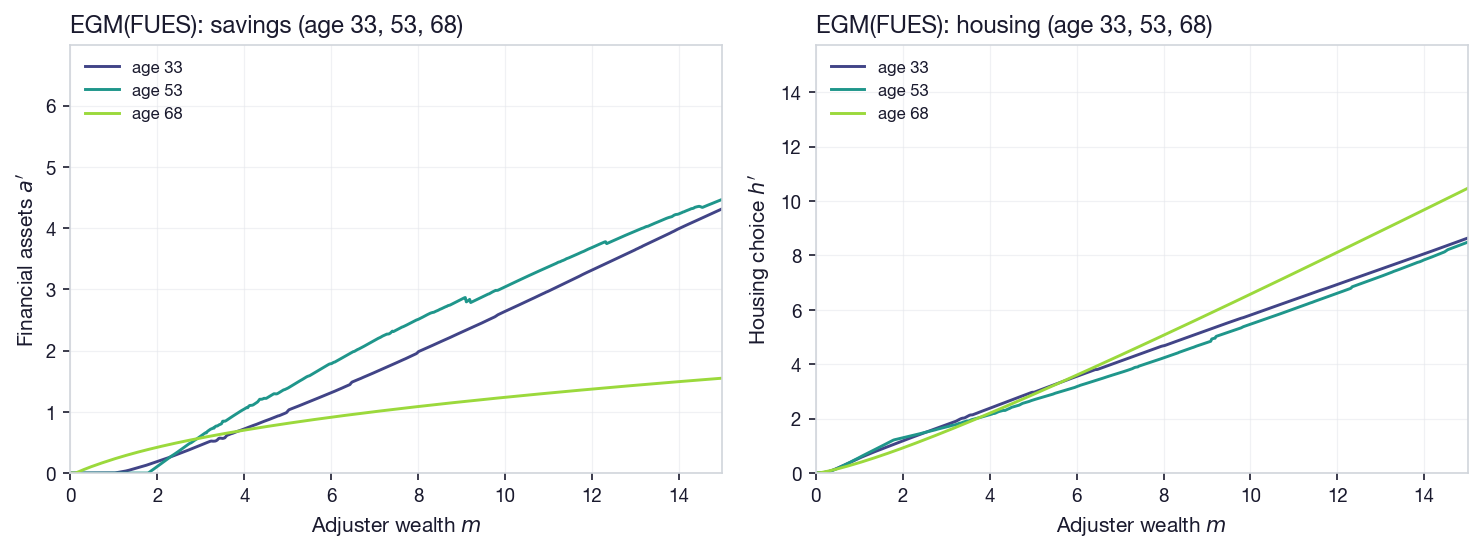

In [ ]:
fig = nb_plot_adjuster_comparison(
    results, results['FUES']['grids'],
    plot_t=[33, 53, 68], methods_filter=['FUES'])

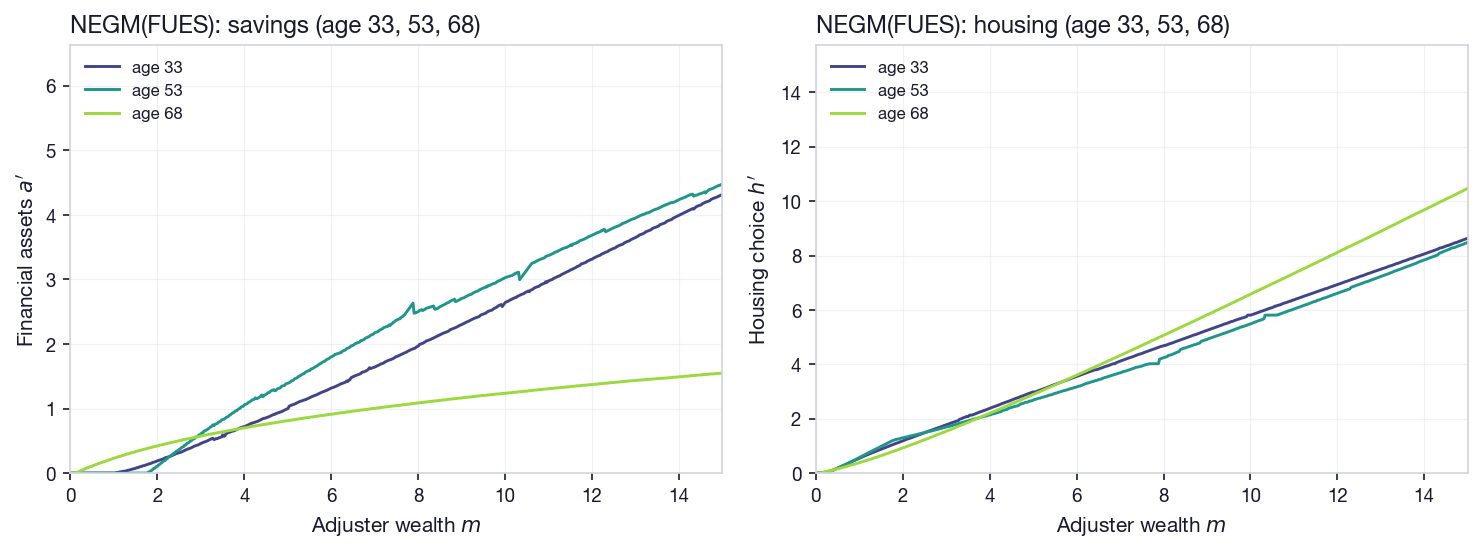

In [ ]:
fig = nb_plot_adjuster_comparison(
    results, results['NEGM']['grids'],
    plot_t=[33, 53, 68], methods_filter=['NEGM'])

## 4. Adjuster EGM grid

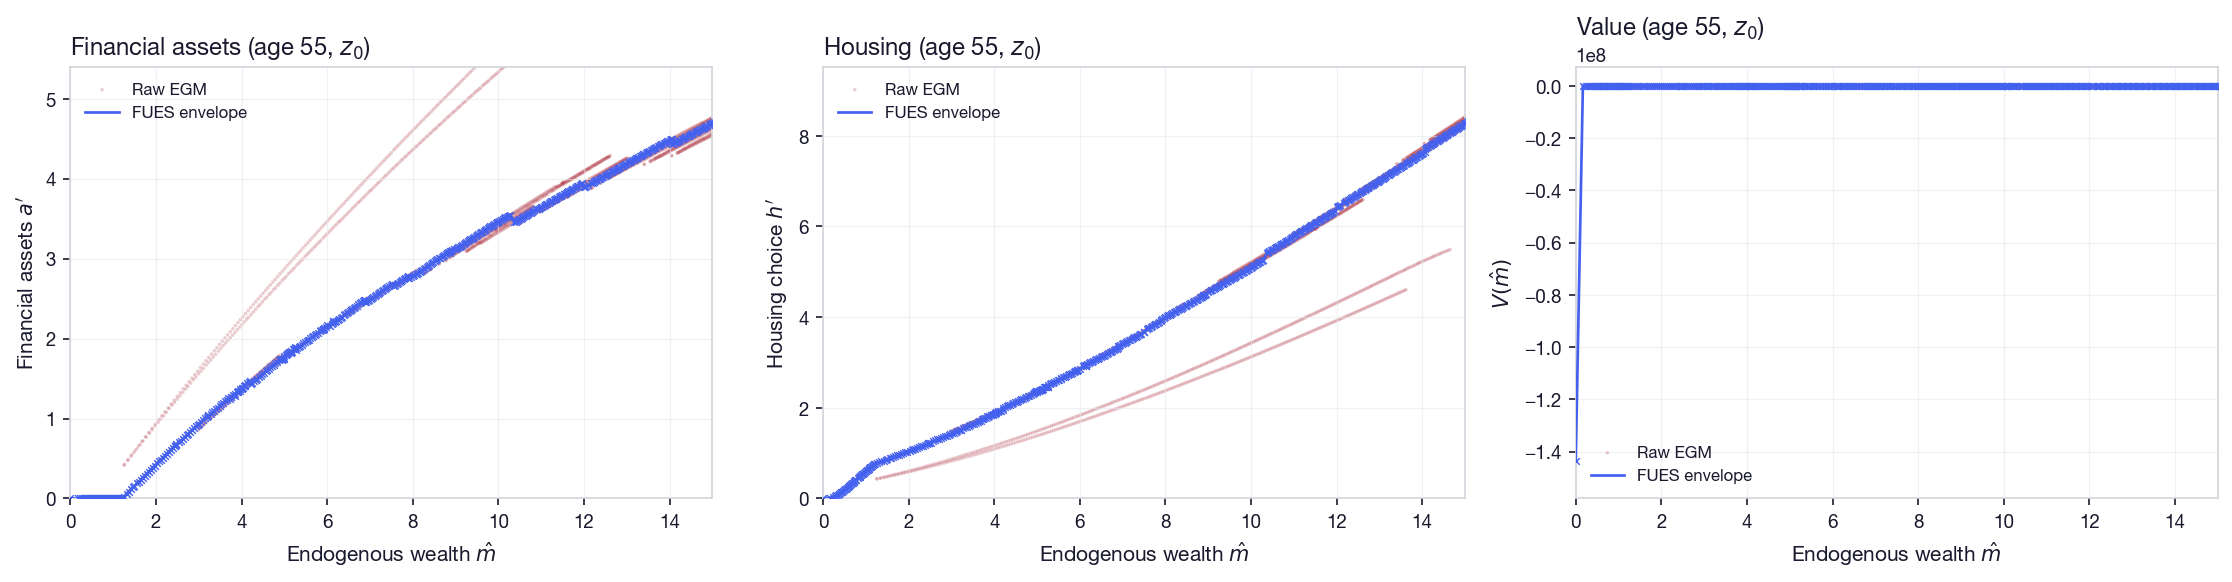

In [ ]:
fig = nb_plot_adjuster_egm(
    results['FUES']['nest'],
    results['FUES']['grids'], plot_t=55)

In [ ]:
# ── Interactive plotly (zoom/pan to inspect dense crossings) ──
try:
    from examples.durables.outputs import nb_plot_adjuster_egm_interactive
    fig_a, fig_h, fig_v = nb_plot_adjuster_egm_interactive(
        results['FUES']['nest'], results['FUES']['grids'], plot_t=55)
    fig_a.show()
    fig_h.show()
    fig_v.show()
except Exception as e:
    print(f'Interactive plots skipped: {e}')

## 5. Keeper policies

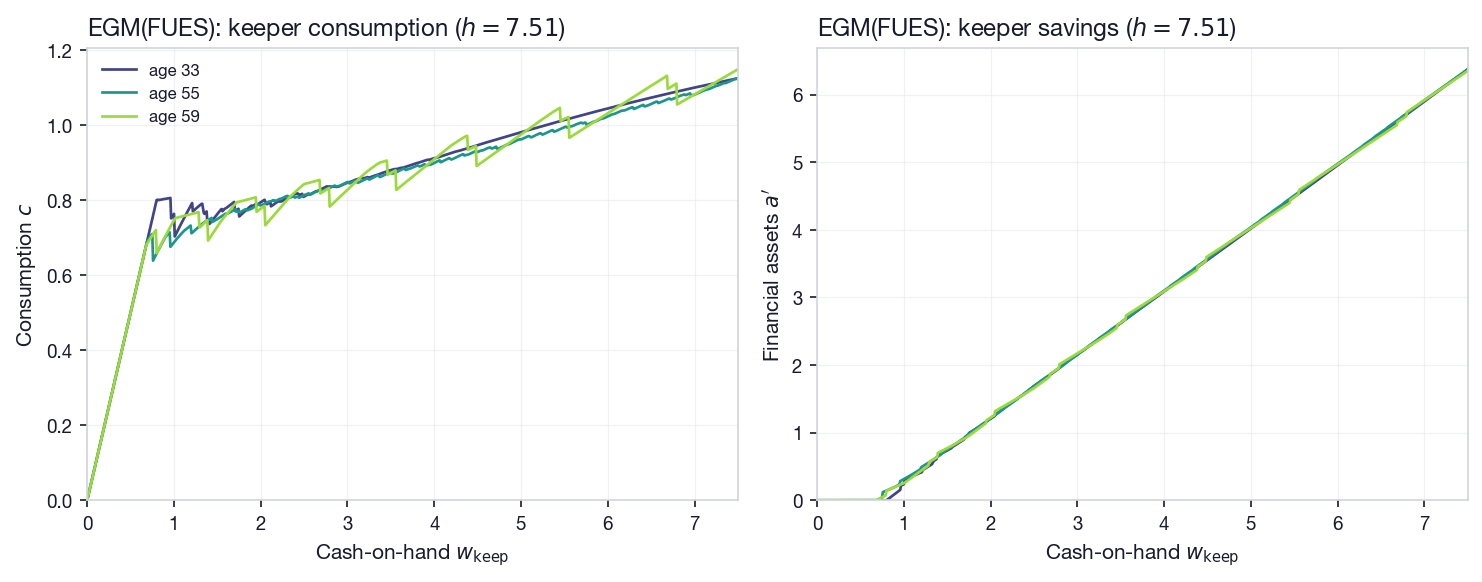

In [ ]:
fig = nb_plot_keeper_policy(results, results['FUES']['grids'],
                           plot_t=[33, 55, 59], methods_filter=['FUES'])

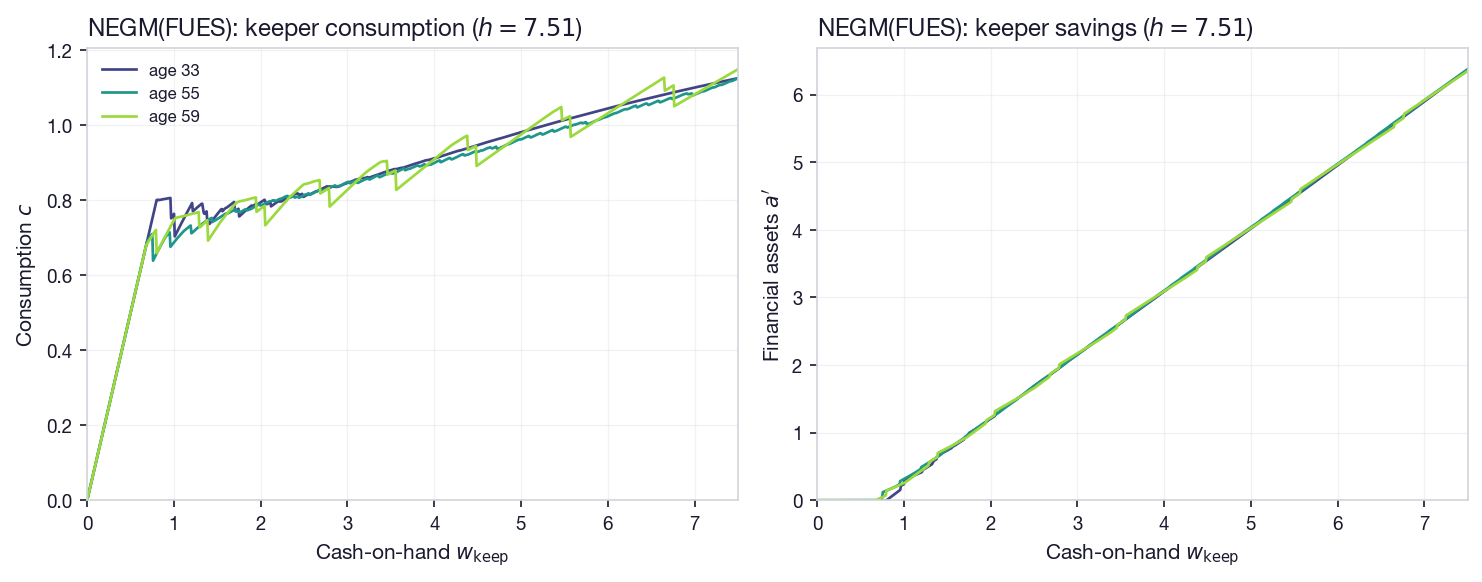

In [ ]:
fig = nb_plot_keeper_policy(results, results['NEGM']['grids'],
                           plot_t=[33, 55, 59], methods_filter=['NEGM'])

### Keeper EGM grid

In [ ]:
for method in ['FUES', 'NEGM']:
    labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
    print(f'{labels[method]}')
    fig = nb_plot_keeper_egm(
        results[method]['nest'],
        results[method]['grids'], plot_t=33)
    if fig is not None:
        fig.show()

EGM(FUES)
No keeper cntn data — run with store_cntn=True and generic EGM path
NEGM(FUES)
No keeper cntn data — run with store_cntn=True and generic EGM path


### Value functions (certainty-equivalent)

## 6. Euler equation errors

In [ ]:
euler_results = {}

for method in ['FUES', 'NEGM']:
    r = results[method]
    sim_data = simulate_lifecycle(r['nest'], r['grids'], N=10_000, seed=41)
    euler_c = evaluate_euler_c(sim_data, r['nest'], r['grids'])
    euler_h = evaluate_euler_h(sim_data, r['nest'], r['grids'])
    euler_results[method] = {
        'euler_c': euler_c, 'euler_h': euler_h, 'euler': euler_c,
        'stats_c': compute_euler_stats(euler_c, sim_data['discrete']),
        'stats_h': compute_euler_stats(euler_h, sim_data['discrete']),
        'stats': compute_euler_stats(euler_c, sim_data['discrete']),
        'sim_data': sim_data,
    }

print('Simulation complete (N = 10,000)')

Simulation complete (N = 10,000)


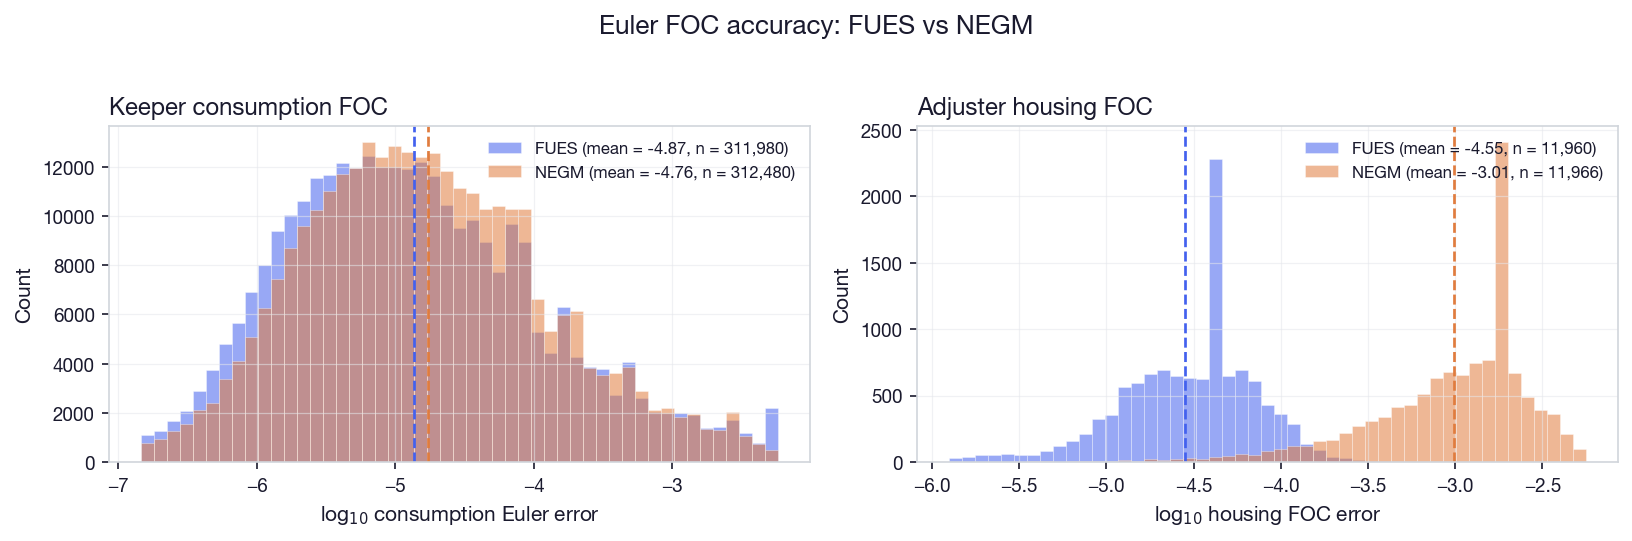

In [ ]:
fig = plot_euler_histogram(euler_results)

## 7. Comparison of aggregates

In [ ]:
rows = [build_comparison_row(m, results, euler_results)
        for m in ['FUES', 'NEGM']]
Markdown(generate_vertical_comparison(
    rows, caption='EGM(FUES) vs NEGM(FUES)'))

### EGM(FUES) vs NEGM(FUES)

| | **EGM(FUES)** | **NEGM(FUES)** |
|:---|:---:|:---:|
| **Timing** |  |  |
| Keeper (ms/period) | 1035 | 1335 |
| Adjuster (ms/period) | 129 | 432 |
| Total (ms/period) | 3617 | 4638 |
| **Euler errors ($\log_{10}$)** |  |  |
| Consumption: keeper | -4.87 | -4.76 |
| Consumption: adjuster | -4.75 | -4.76 |
| Consumption: all | -4.86 | -4.76 |
| Housing: adjuster | -4.55 | -3.01 |
| **Simulation** |  |  |
| CE utility | 5,085.60 | 5,085.55 |
| Mean consumption ($) | 62,111 | 62,107 |
| Mean fin. assets ($) | 67,199 | 67,420 |
| Mean housing ($) | 211,354 | 211,179 |
| Adjustment rate (%) | 11.8 | 11.7 |

## 8. Lifecycle profiles

Lifecycle plot saved to _nb_plots/FUES/simulation/lifecycle.png
EGM(FUES)


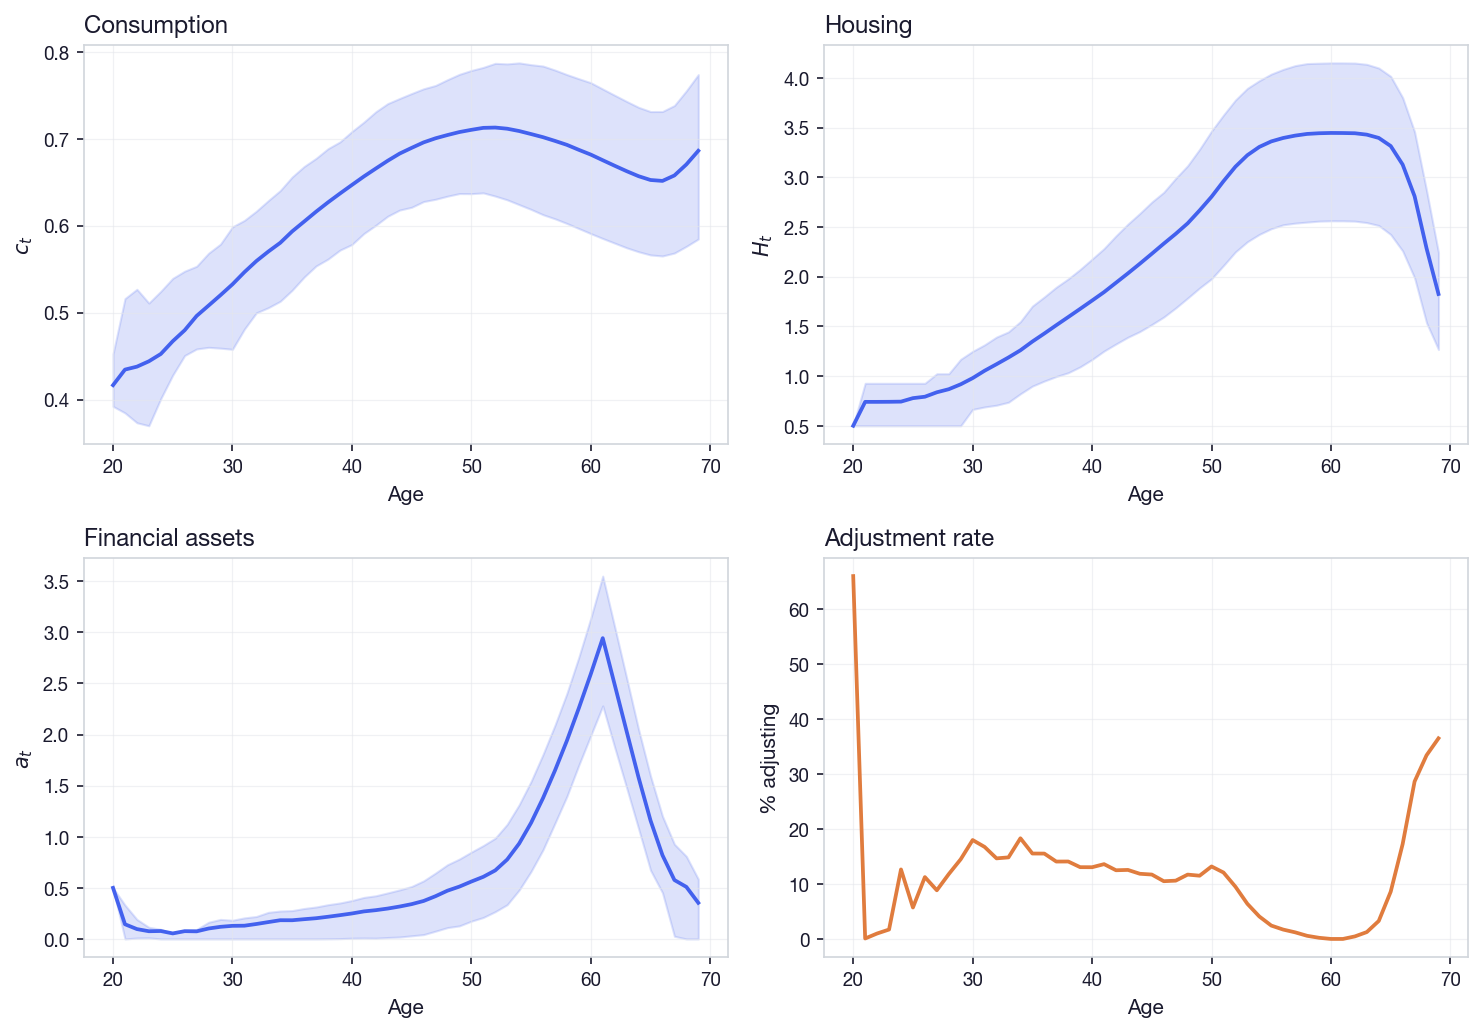

Lifecycle plot saved to _nb_plots/NEGM/simulation/lifecycle.png
NEGM(FUES)


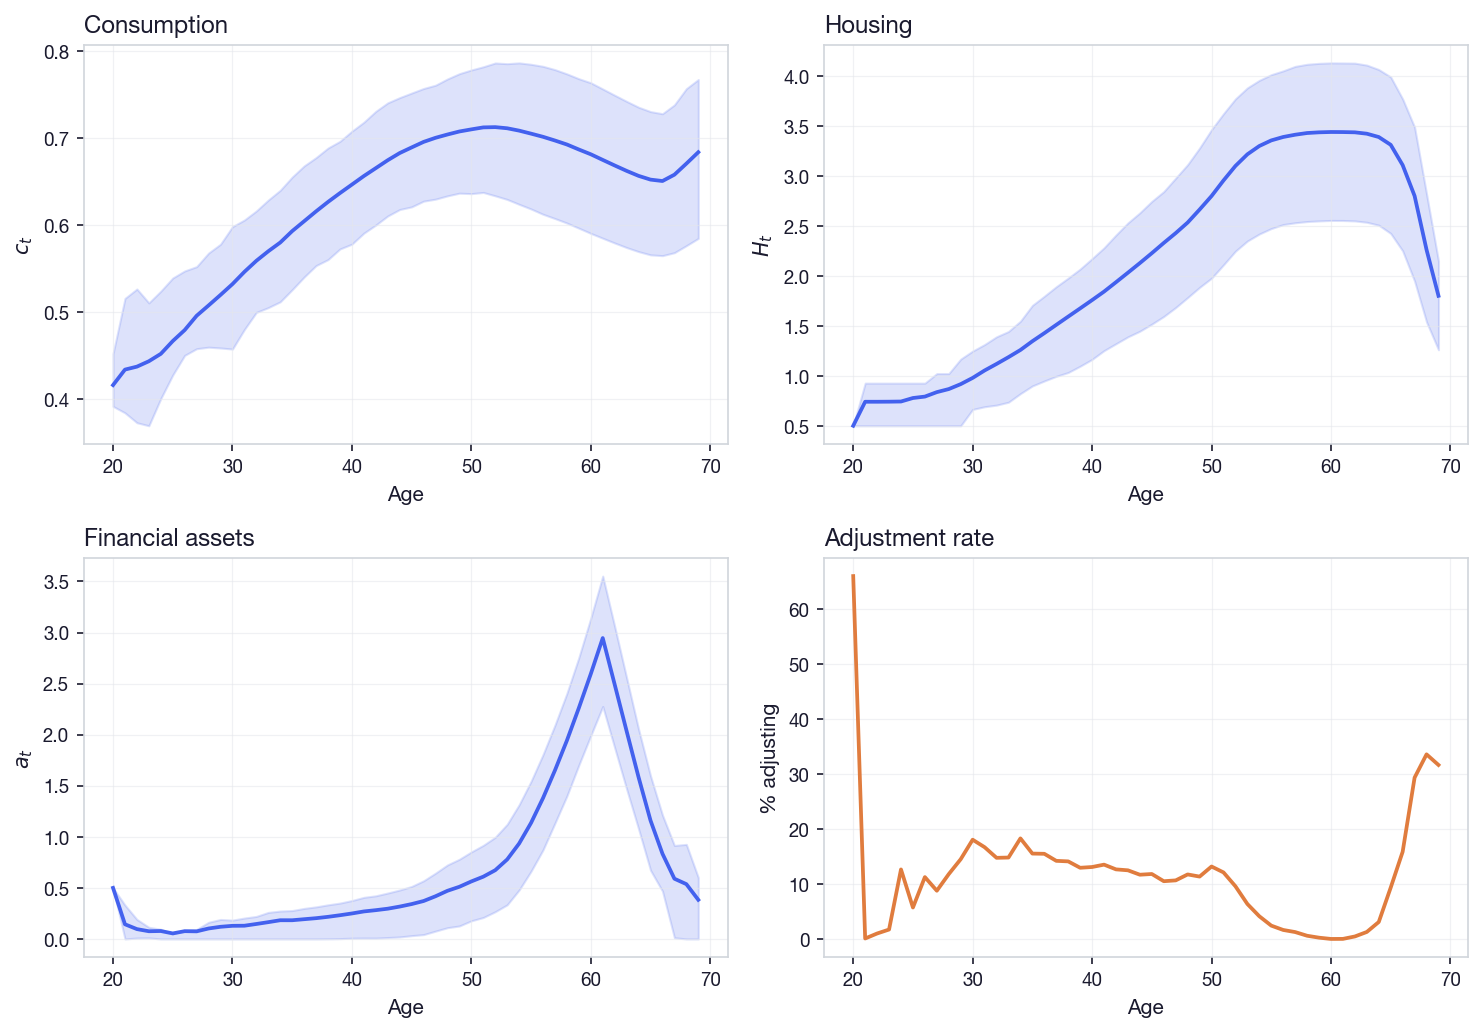

In [ ]:
from IPython.display import Image, display

for method in ['FUES', 'NEGM']:
    er = euler_results[method]
    r = results[method]
    plot_lifecycle(er['sim_data'], er['euler'], r['nest'],
                   output_dir=f'_nb_plots/{method}')
    path = f'_nb_plots/{method}/simulation/lifecycle.png'
    if os.path.exists(path):
        print(f'{labels[method]}')
        display(Image(path))

In [ ]:
_st0 = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_t0 = int(_st0.calibration['t0'])
_T = int(_st0.settings['T'])
_norm = 1.0 / float(_st0.settings['normalisation'])
labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}

for method in ['FUES', 'NEGM']:
    sd = euler_results[method]['sim_data']
    tbl = generate_cohort_table(sd, _t0, _T, _norm)
    display(Markdown(f'**{labels[method]}**\n\n{tbl}'))

**EGM(FUES)**

| Age | $\bar{c}$ | SD($c$) | $\bar{a}$ | SD($a$) | $\bar{H}$ | SD($H$) |
|:---|---:|---:|---:|---:|---:|---:|
| 20–24 | 43,705.96 | 7,595.97 | 17,863.59 | 19,209.92 | 69,286.52 | 20,348.10 |
| 25–29 | 49,427.86 | 9,085.06 | 8,509.30 | 13,913.90 | 83,820.50 | 35,574.16 |
| 30–34 | 55,782.59 | 9,261.76 | 15,045.17 | 19,795.88 | 111,967.97 | 54,189.78 |
| 35–39 | 61,567.55 | 9,684.11 | 20,575.64 | 25,567.07 | 151,112.61 | 70,475.52 |
| 40–44 | 66,542.36 | 9,887.96 | 28,300.58 | 32,992.57 | 194,121.30 | 85,553.88 |
| 45–49 | 69,961.83 | 9,986.40 | 42,299.36 | 42,315.50 | 243,909.14 | 102,027.33 |
| 50–54 | 71,127.63 | 11,071.58 | 71,017.07 | 55,963.17 | 307,934.62 | 117,120.43 |
| 55–59 | 69,703.83 | 12,393.51 | 167,269.75 | 82,274.81 | 341,046.87 | 119,523.98 |
| 60–64 | 66,917.71 | 12,495.69 | 232,741.07 | 97,911.15 | 343,128.08 | 119,879.02 |
| 65–69 | 66,372.74 | 12,896.86 | 68,367.86 | 56,046.30 | 267,208.48 | 120,204.40 |

**NEGM(FUES)**

| Age | $\bar{c}$ | SD($c$) | $\bar{a}$ | SD($a$) | $\bar{H}$ | SD($H$) |
|:---|---:|---:|---:|---:|---:|---:|
| 20–24 | 43,700.13 | 7,598.34 | 17,854.16 | 19,217.15 | 69,306.11 | 20,340.44 |
| 25–29 | 49,426.69 | 9,080.52 | 8,517.73 | 13,929.13 | 83,840.01 | 35,566.67 |
| 30–34 | 55,785.51 | 9,264.85 | 15,038.13 | 19,791.68 | 111,998.52 | 54,199.83 |
| 35–39 | 61,571.17 | 9,686.66 | 20,564.41 | 25,549.25 | 151,131.32 | 70,482.52 |
| 40–44 | 66,548.69 | 9,888.81 | 28,268.14 | 32,968.10 | 194,132.56 | 85,564.63 |
| 45–49 | 69,970.45 | 9,987.73 | 42,259.15 | 42,237.20 | 243,899.89 | 102,023.70 |
| 50–54 | 71,126.47 | 11,062.01 | 71,177.88 | 56,065.68 | 307,740.43 | 117,013.31 |
| 55–59 | 69,697.40 | 12,390.05 | 167,444.43 | 82,471.47 | 340,872.25 | 119,520.07 |
| 60–64 | 66,907.62 | 12,493.54 | 233,004.66 | 98,135.85 | 342,945.59 | 119,852.20 |
| 65–69 | 66,338.67 | 12,893.09 | 70,073.01 | 56,706.16 | 265,928.30 | 120,464.34 |